In [ ]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from scipy.io import arff
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

train_data, train_meta = arff.loadarff("Dataset/Wafer/Wafer_TRAIN.arff")
df_train = pd.DataFrame(train_data)
df_train

,att1,att2,att3,att4,att5,att6,att7,att8,att9,att10,...,att144,att145,att146,att147,att148,att149,att150,att151,att152,target
0,-1.602294,-1.670823,-1.693666,-1.699377,-1.699377,-1.703660,-1.703660,-1.703660,-1.703660,-1.703660,...,-1.145432,-1.145432,-1.145432,-1.145432,-1.145432,-1.145432,-1.145432,-1.145432,-1.145432,b'1'
1,1.084591,1.084591,1.084591,1.065308,1.065308,1.065308,1.065308,1.065308,1.065308,1.084591,...,1.065308,1.065308,1.065308,1.065308,1.065308,1.065308,1.065308,1.065308,1.065308,b'1'
2,0.362689,0.362689,0.362689,0.393316,0.362689,0.362689,0.362689,0.362689,0.362689,0.362689,...,0.393316,0.393316,0.362689,0.393316,0.393316,0.393316,0.393316,0.393316,0.393316,b'1'
3,-1.094523,-1.094523,-1.094523,-1.096732,-1.094523,-1.096732,-1.094523,-1.094523,-1.094523,-1.096732,...,-1.096732,-1.096732,-1.096732,-1.096732,-1.096732,-1.096732,-1.096732,-1.096732,-1.096732,b'1'
4,-1.103761,-1.103761,-1.103761,-1.103761,-1.103761,-1.103761,-1.103761,-1.103761,-1.103761,-1.103761,...,-1.103761,-1.103761,-1.103761,-1.103761,-1.103761,-1.103761,-1.103761,-1.103761,-1.103761,b'1'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.621709,-1.644240,-1.652689,-1.658322,-1.658322,-1.662546,-1.658322,-1.662546,-1.662546,-1.662546,...,-1.111952,-1.111952,-1.111952,-1.111952,-1.111952,-1.111952,-1.111952,-1.111952,-1.111952,b'1'
996,0.813520,0.813520,0.813520,0.813520,0.813520,0.813520,0.813520,0.813520,0.813520,0.813520,...,0.758193,0.758193,0.758193,0.758193,0.758193,0.758193,0.758193,0.758193,0.758193,b'1'
997,-0.832885,-0.977293,-0.923421,-0.953684,-0.936716,-0.946148,-0.943889,-0.938630,-0.952115,-0.928769,...,-0.942518,-0.941143,-0.943985,-0.939208,-0.946774,-0.934842,-0.953684,-0.923421,-0.977293,b'-1'
998,0.930389,0.930389,0.930389,0.930389,0.930389,0.930389,0.930389,0.930389,0.865309,0.930389,...,0.930389,0.930389,0.930389,0.930389,0.930389,0.930389,0.930389,0.930389,0.930389,b'1'


In [ ]:
test_data, test_meta = arff.loadarff("Dataset/Wafer/Wafer_TEST.arff")
df_test = pd.DataFrame(test_data)
df_test

,att1,att2,att3,att4,att5,att6,att7,att8,att9,att10,...,att144,att145,att146,att147,att148,att149,att150,att151,att152,target
0,-1.079707,-1.083256,-1.079707,-1.079707,-1.079707,-1.079707,-1.079707,-1.079707,-1.079707,-1.079707,...,-1.079707,-1.079707,-1.079707,-1.079707,-1.079707,-1.079707,-1.079707,-1.079707,-1.079707,b'1'
1,-1.080197,-1.078021,-1.078021,-1.078021,-1.078021,-1.078021,-1.080197,-1.078021,-1.078021,-1.080197,...,-1.112846,-1.115023,-1.117199,-1.119376,-1.121553,-1.123729,-1.125906,-1.128082,-1.130259,b'1'
2,-1.154060,-1.154060,-1.154060,-1.154060,-1.154060,-1.154060,-1.154060,-1.154060,-1.154060,-1.154060,...,-1.154060,-1.154060,-1.154060,-1.154060,-1.154060,-1.154060,-1.154060,-1.154060,-1.154060,b'1'
3,-1.658965,-1.696605,-1.705291,-1.711082,-1.711082,-1.715425,-1.715425,-1.715425,-1.715425,-1.715425,...,-1.149382,-1.149382,-1.149382,-1.149382,-1.149382,-1.149382,-1.149382,-1.149382,-1.149382,b'1'
4,-1.201221,-1.199042,-1.199042,-1.201221,-1.199042,-1.199042,-1.199042,-1.199042,-1.199042,-1.199042,...,-1.183789,-1.181610,-1.179431,-1.177251,-1.175072,-1.172893,-1.170714,-1.168535,-1.166356,b'1'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6159,1.058364,1.058364,1.077259,1.058364,1.077259,1.077259,1.058364,1.058364,1.077259,1.077259,...,1.058364,1.058364,1.058364,1.058364,1.058364,1.058364,1.058364,1.058364,1.058364,b'1'
6160,-0.883897,-1.037149,-0.979977,-1.012094,-0.992098,-1.004760,-1.000370,-0.996084,-1.011200,-0.981698,...,-1.000244,-0.998784,-1.001801,-0.996731,-1.004760,-0.992098,-1.012094,-0.979977,-1.037149,b'-1'
6161,0.700052,0.874868,0.836440,0.798761,0.786091,0.856247,0.849871,0.772646,0.900171,0.763408,...,0.781052,0.779912,0.782268,0.778308,0.784578,0.774691,0.790305,0.765226,0.809869,b'-1'
6162,-1.517047,-1.580021,-1.602920,-1.608645,-1.608645,-1.608645,-1.608645,-1.608645,-1.608645,-1.612939,...,-1.059059,-1.059059,-1.059059,-1.059059,-1.059059,-1.059059,-1.059059,-1.059059,-1.059059,b'1'


In [ ]:
'Clean the data by converting the label into int'
df_train['target'] = df_train['target'].apply(lambda x:1 if x == b'1' else 0)
df_test['target'] = df_test['target'].apply(lambda x:1 if x == b'1' else 0)

In [ ]:
print(f"Train label counts:\n {df_train['target'].value_counts()}")
print(f"Test label counts:\n {df_test['target'].value_counts()}")

Train label counts:
 target
1    903
0     97
Name: count, dtype: int64
Test label counts:
 target
1    5499
0     665
Name: count, dtype: int64


In [ ]:
'Upsample the training set'
# Separate minority (abnormal) and majority (normal) classes
df_train_majority = df_train[df_train['target'] == 1]
df_train_minority = df_train[df_train['target'] == 0]

# Upsample minority class
df_minority_upsampled = resample(
    df_train_minority,
    replace=True,  # sample with replacement
    n_samples=len(df_train_majority),  # match normal count
    random_state=42
)

# Combine back
df_train_balanced = pd.concat([df_train_majority, df_minority_upsampled], ignore_index=True)

# Shuffle
df_train_balanced = df_train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check new balance
print("Balanced train label counts:\n", df_train_balanced['target'].value_counts())

Balanced train label counts:
 target
0    903
1    903
Name: count, dtype: int64


In [ ]:
'Separte the features and labels'
X_train = df_train_balanced.drop('target',axis=1).astype(float).values
y_train = df_train_balanced['target'].values

X_train, y_train

(array([[-0.80541924, -0.94506483, -0.89296883, ..., -0.92223396,
         -0.89296883, -0.94506483],
        [-1.2535202 , -1.2498905 , -1.2498905 , ..., -1.2535202 ,
         -1.2535202 , -1.2535202 ],
        [-1.1532809 , -1.1532809 , -1.1532809 , ..., -1.1554215 ,
         -1.1554215 , -1.1554215 ],
        ...,
        [-1.58882   , -1.6532319 , -1.6766544 , ..., -1.0208243 ,
         -1.0149687 , -1.0091131 ],
        [-0.80175339, -0.94076319, -0.88890438, ..., -0.91803627,
         -0.88890438, -0.94076319],
        [-0.83649094, -0.98150593, -0.92743175, ..., -0.95780583,
         -0.92741181, -0.98151739]]),
 array([0, 1, 1, ..., 1, 0, 0]))

In [ ]:
'Separte the features and labels'
X_test = df_test.drop('target',axis=1).astype(float).values
y_test = df_test['target'].values

X_test, y_test

(array([[-1.0797068 , -1.0832556 , -1.0797068 , ..., -1.0797068 ,
         -1.0797068 , -1.0797068 ],
        [-1.0801972 , -1.0780206 , -1.0780206 , ..., -1.1259058 ,
         -1.1280824 , -1.1302591 ],
        [-1.1540601 , -1.1540601 , -1.1540601 , ..., -1.1540601 ,
         -1.1540601 , -1.1540601 ],
        ...,
        [ 0.70005233,  0.87486827,  0.83643961, ...,  0.79030471,
          0.76522617,  0.80986946],
        [-1.5170472 , -1.5800206 , -1.60292   , ..., -1.0590593 ,
         -1.0590593 , -1.0590593 ],
        [-1.1325453 , -1.1325453 , -1.1325453 , ..., -1.1325453 ,
         -1.1325453 , -1.1325453 ]]),
 array([1, 1, 1, ..., 0, 1, 1]))

In [ ]:
'Normalize the data'
scaler = StandardScaler()
#Use X_train mean as a comparison point
X_train = scaler.fit_transform(X_train)
#Compare the testing to the training
X_test = scaler.transform(X_test)

In [ ]:
'Change the shape of both set in order to pass through CNN'
print(f"X_train shape before reshaping {X_train.shape}")
X_train = X_train.reshape((X_train.shape[0],X_train.shape[1],1))
print(f"X_train shape after reshaping {X_train.shape}")

print(f"X_test shape before reshaping {X_test.shape}")
X_test = X_test.reshape((X_test.shape[0],X_test.shape[1],1))
print(f"X_test shape after reshaping {X_test.shape}")

X_train shape before reshaping (1806, 152)
X_train shape after reshaping (1806, 152, 1)
X_test shape before reshaping (6164, 152)
X_test shape after reshaping (6164, 152, 1)


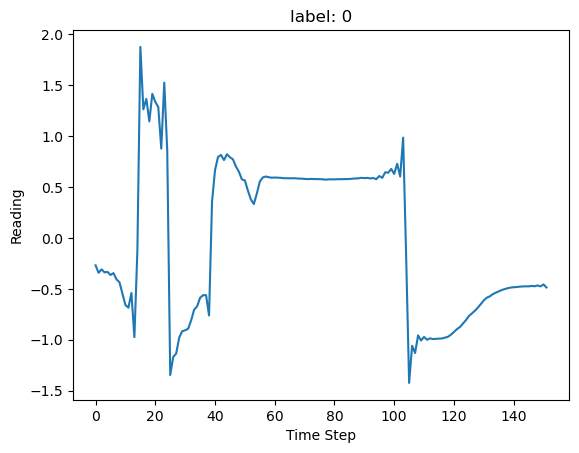

In [ ]:
"Let visualize the training set"
plt.plot(X_train[0].squeeze())
plt.title(f"label: {y_train[0]}")
plt.xlabel("Time Step")
plt.ylabel("Reading")
plt.show()

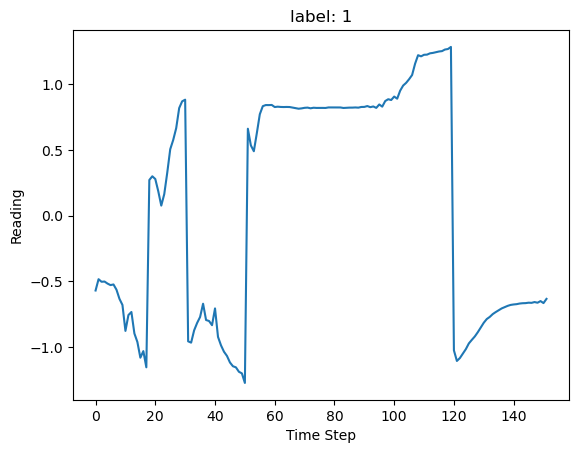

In [ ]:
"Let visualize the testing set"
plt.plot(X_test[0].squeeze())
plt.title(f"label: {y_test[0]}")
plt.xlabel("Time Step")
plt.ylabel("Reading")
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

model = Sequential([
    # ── Block 1 ──
    Conv1D(32, kernel_size=7, activation='relu', padding='same', kernel_regularizer=l2(1e-3), input_shape=(152, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # ── Block 2 ──
    Conv1D(64, kernel_size=5, activation='relu', padding='same', kernel_regularizer=l2(1e-3)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.4),

    # ── Block 3 ──
    Conv1D(128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(1e-3)),
    BatchNormalization(),

    # ── Feature Aggregation ──
    GlobalAveragePooling1D(),

    # ── Classifier ──
    Dense(64, activation='relu', kernel_regularizer=l2(1e-3)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 152, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 152, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 76, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 76, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 76, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 76, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 38, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,481 (173.75 KB)

 Trainable params: 44,033 (172.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping: stop if val_loss doesn’t improve for 50 epochs
es = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
# Save best model to local file
mc = ModelCheckpoint('wafer_cnn_best.h5', save_best_only=True)

# Split training set into train/val sets (80/20)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    shuffle=True,
    callbacks=[es, mc],
    verbose=1
)

Epoch 1/50
41/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9906 - loss: 0.0944

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9912 - loss: 0.0933 - val_accuracy: 0.9945 - val_loss: 0.0863
Epoch 2/50
42/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9998 - loss: 0.0732

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9997 - loss: 0.0732 - val_accuracy: 0.9945 - val_loss: 0.0817
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9994 - loss: 0.0710 - val_accuracy: 0.9945 - val_loss: 0.0828
Epoch 4/50
40/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9920 - loss: 0.0777

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9925 - loss: 0.0772 - val_accuracy: 0.9945 - val_loss: 0.0809
Epoch 5/50
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9985 - loss: 0.0690

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9986 - loss: 0.0689 - val_accuracy: 0.9945 - val_loss: 0.0756
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9965 - loss: 0.0692 - val_accuracy: 0.9945 - val_loss: 0.0810
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9998 - loss: 0.0626 - val_accuracy: 0.9945 - val_loss: 0.0787
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9996 - loss: 0.0614 - val_accuracy: 0.9945 - val_loss: 0.0810
Epoch 9/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9986 - loss: 0.0642 - val_accuracy: 0.9945 - val_loss: 0.0764
Epoch 10/50
41/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0575

...

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0464 - val_accuracy: 0.9945 - val_loss: 0.0602
Epoch 24/50
43/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9995 - loss: 0.0433

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9994 - loss: 0.0433 - val_accuracy: 0.9945 - val_loss: 0.0559
Epoch 25/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9985 - loss: 0.0454 - val_accuracy: 0.9945 - val_loss: 0.0651
Epoch 26/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0439 - val_accuracy: 0.9945 - val_loss: 0.0664
Epoch 27/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9998 - loss: 0.0422 - val_accuracy: 0.9945 - val_loss: 0.0668
Epoch 28/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9976 - loss: 0.0428 - val_accuracy: 0.9945 - val_loss: 0.0588
Epoch 29/50
42/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9972 - loss: 0.0442

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9971 - loss: 0.0445 - val_accuracy: 0.9945 - val_loss: 0.0487
Epoch 30/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9986 - loss: 0.0437 - val_accuracy: 0.9945 - val_loss: 0.0532
Epoch 31/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9989 - loss: 0.0446 - val_accuracy: 0.9945 - val_loss: 0.0546
Epoch 32/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9990 - loss: 0.0408 - val_accuracy: 0.9945 - val_loss: 0.0640
Epoch 33/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9988 - loss: 0.0422 - val_accuracy: 0.9945 - val_loss: 0.0578
Epoch 34/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9989 - loss: 0.0430 - val_accuracy: 0.9945 - val_loss: 0.0607
Epoch 35/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9982 - loss: 0.0414 - val_accuracy: 0.9945 - val_loss: 0.0575
Epoch 36/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0375 - val_accuracy: 0.9945 - val_loss: 0

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9994 - loss: 0.0371 - val_accuracy: 0.9945 - val_loss: 0.0450
Epoch 38/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9960 - loss: 0.0452 - val_accuracy: 0.9972 - val_loss: 0.0457
Epoch 39/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9970 - loss: 0.0438 - val_accuracy: 0.9945 - val_loss: 0.0538
Epoch 40/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9973 - loss: 0.0419 - val_accuracy: 0.9945 - val_loss: 0.0580
Epoch 41/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9961 - loss: 0.0425 - val_accuracy: 0.9945 - val_loss: 0.0579
Epoch 42/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9960 - loss: 0.0464 - val_accuracy: 0.9945 - val_loss: 0.0560
Epoch 43/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9987 - loss: 0.0392 - val_accuracy: 0.9945 - val_loss: 0.0513
Epoch 44/50
42/46 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0376

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9999 - loss: 0.0377 - val_accuracy: 0.9945 - val_loss: 0.0439
Epoch 45/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9998 - loss: 0.0348 - val_accuracy: 0.9945 - val_loss: 0.0441
Epoch 46/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9964 - loss: 0.0423 - val_accuracy: 0.9890 - val_loss: 0.0660
Epoch 47/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9822 - loss: 0.0716 - val_accuracy: 0.9945 - val_loss: 0.0516
Epoch 48/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9987 - loss: 0.0404 - val_accuracy: 0.9945 - val_loss: 0.0593
Epoch 49/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9980 - loss: 0.0447 - val_accuracy: 0.9945 - val_loss: 0.0569
Epoch 50/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9948 - loss: 0.0448 - val_accuracy: 0.9945 - val_loss: 0.0554


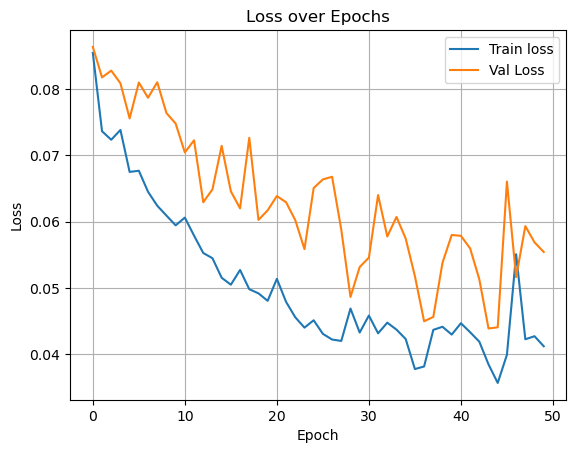

In [ ]:
#plot loss over Epochs
plt.figure()
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

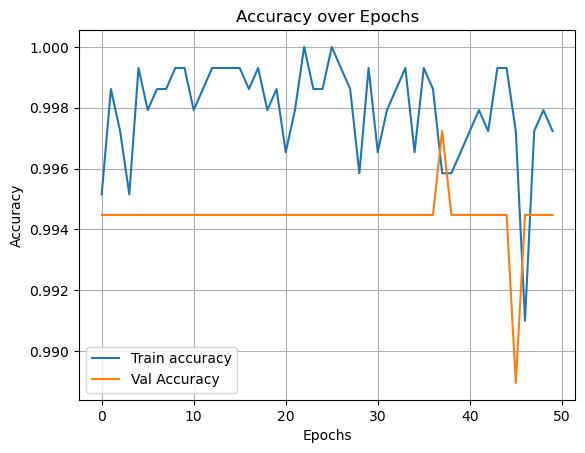

In [ ]:
#Plot Accuracy over Epochs
plt.figure()
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")
print(f"Test Loss: {loss:.4f}")

y_pred = (model.predict(X_test)>0.5).astype(int).flatten()
print(f"Test F1_score: {f1_score(y_test,y_pred):.4f}")

Test Accuracy: 0.9953
Test Loss: 0.0444
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test F1_score: 0.9974


193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


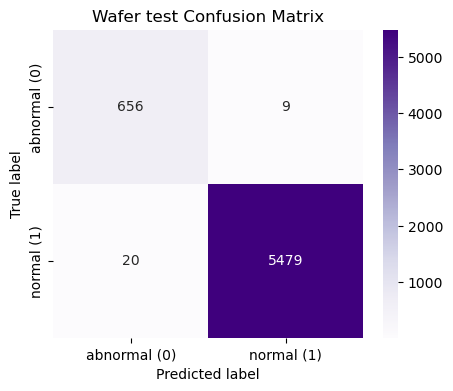

              precision    recall  f1-score   support

abnormal (0)       0.97      0.99      0.98       665
  normal (1)       1.00      1.00      1.00      5499

    accuracy                           1.00      6164
   macro avg       0.98      0.99      0.99      6164
weighted avg       1.00      1.00      1.00      6164



In [ ]:
'Confusion Matrix'
#Get binary predictions
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int).flatten()

#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['abnormal (0)', 'normal (1)']

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True, fmt='d', cmap='Purples',
            xticklabels=labels,yticklabels=labels)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Wafer test Confusion Matrix')
plt.show()

#Classicfication Report
print(classification_report(y_test,y_pred,target_names=labels))

In [ ]:
'Save the model'
import joblib
model.save("wafer_cnn_final.keras")
joblib.dump(scaler, "wafer_scaler.pkl")

['wafer_scaler.pkl']

#### Interpretability - SHAP


In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
model.summary()

X_train shape: (1806, 152, 1)
y_train shape: (1806,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 152, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 152, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 76, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 76, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 76, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 76, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 38, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,549 (517.77 KB)

 Trainable params: 44,033 (172.00 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 88,068 (344.02 KB)

In [ ]:
import shap
import numpy as np

# Sample background for SHAP (100 random samples)
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

# Initialize DeepExplainer
explainer = shap.DeepExplainer(model, background)

# Pick 10 test samples (use training or test)
X_to_explain = X_train[:10]  # or X_test[:10] if you're testing inference

# Run SHAP
shap_values = explainer.shap_values(X_to_explain)

# Confirm shapes
print(f"shap_values type: {type(shap_values)}")
print(f"len(shap_values): {len(shap_values)}")
print(f"shap_values[0] shape: {shap_values[0].shape}")  # Expected: (10, 152, 1)

/opt/anaconda3/lib/python3.12/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 152, 1))']
  warnings.warn(msg)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 152, 1))']
  warnings.warn(msg)


shap_values type: <class 'numpy.ndarray'>
len(shap_values): 10
shap_values[0] shape: (152, 1, 1)


/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(10, 152, 1))']
  warnings.warn(msg)


In [ ]:
# Step 1: Stack list of SHAP values into 3D tensor
shap_tensor = np.stack(shap_values, axis=0)  # shape: (10, 152, 1, 1)

# Step 2: Squeeze the last two singleton dimensions → (10, 152)
shap_values_2d = shap_tensor.squeeze(-1).squeeze(-1)

# Step 3: Confirm shape matches input
X_to_explain_2d = X_to_explain.squeeze(-1)
print("SHAP shape:", shap_values_2d.shape)
print("Input shape:", X_to_explain_2d.shape)

SHAP shape: (10, 152)
Input shape: (10, 152)


/var/folders/k1/8stg9t9s5njbkfx3hdv2vv5r0000gn/T/ipykernel_58984/132511703.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


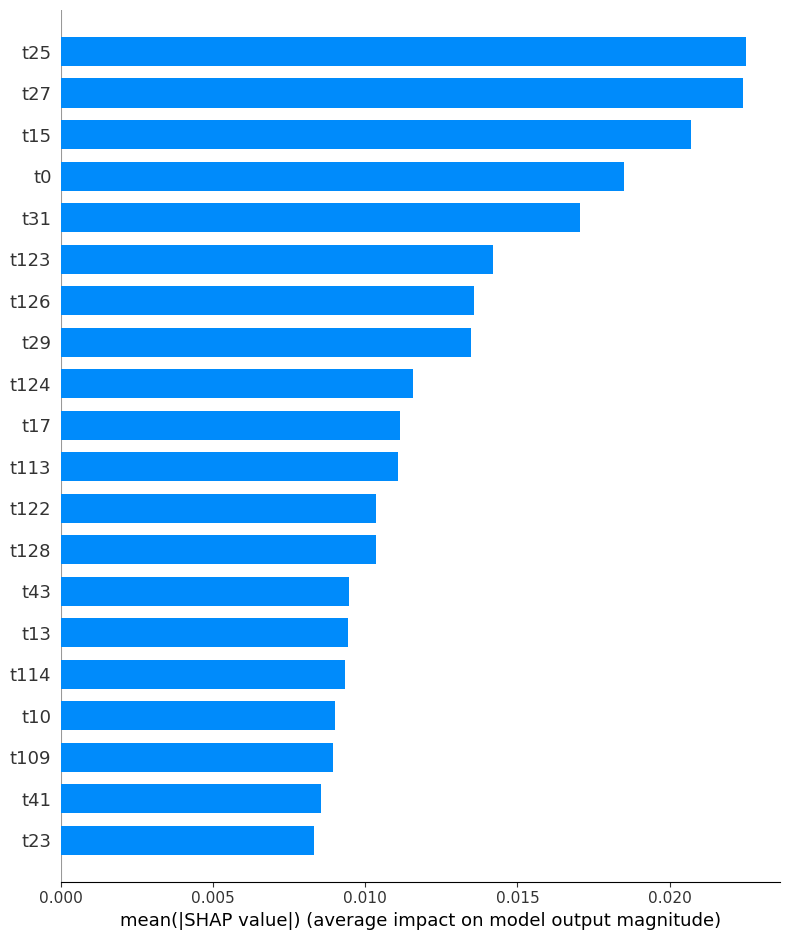

In [ ]:
shap.summary_plot(
    shap_values_2d,
    X_to_explain_2d,
    feature_names=[f"t{i}" for i in range(152)],
    plot_type="bar",   # Try "violin" too
    max_display=20     # Show top 20 most important features
)

In [ ]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
model.summary()

X_test shape: (6164, 152, 1)
y_test shape: (6164,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 152, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 152, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 76, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 76, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 76, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 76, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 38, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,549 (517.77 KB)

 Trainable params: 44,033 (172.00 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 88,068 (344.02 KB)

In [ ]:
import numpy as np

# Predict
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Check matching samples
case_1_indices = np.where((y_test == 1) & (y_pred == 1))[0]
case_2_indices = np.where((y_test == 0) & (y_pred == 1))[0]

print("Case 1: Actual=1, Pred=1 →", case_1_indices[:5])  # Show a few
print("Case 2: Actual=0, Pred=1 →", case_2_indices[:5])  # Show a few

193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Case 1: Actual=1, Pred=1 → [0 1 2 3 4]
Case 2: Actual=0, Pred=1 → [ 352 1145 1653 2057 2744]


In [ ]:
def integrated_gradients(model, baseline, sample, target_class_idx=0, m_steps=50):
    # Ensure float32
    baseline = tf.cast(baseline, tf.float32)
    sample = tf.cast(sample, tf.float32)
    alphas = tf.linspace(0.0, 1.0, m_steps + 1)

    # FIX: Correct the interpolation shape to (m_steps+1, 152, 1)
    interpolated = tf.stack([
        baseline[0] + alpha * (sample[0] - baseline[0])  # shape: (152, 1)
        for alpha in alphas
    ])  # shape: (m_steps+1, 152, 1)

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated, training=False)  # shape: (m_steps+1, 1)
        outputs = preds[:, target_class_idx]         # shape: (m_steps+1,)

    grads = tape.gradient(outputs, interpolated)     # shape: (m_steps+1, 152, 1)
    avg_grads = tf.reduce_mean(grads, axis=0)        # shape: (152, 1)
    ig = (sample - baseline) * avg_grads             # shape: (1, 152, 1)

    return ig.numpy().squeeze()  # shape: (152,)

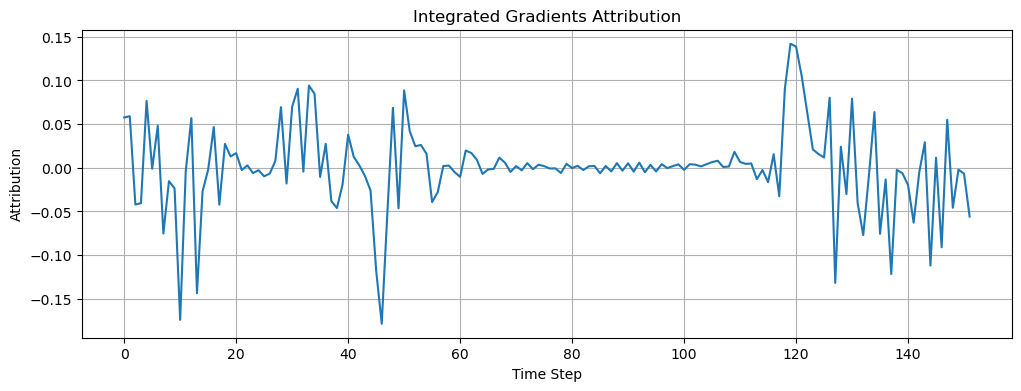

In [ ]:
sample = tf.convert_to_tensor(X_test[0:1], dtype=tf.float32)  # (1, 152, 1)
baseline = tf.zeros_like(sample)

ig_attrib = integrated_gradients(model, baseline, sample)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(ig_attrib)
plt.title("Integrated Gradients Attribution")
plt.xlabel("Time Step")
plt.ylabel("Attribution")
plt.grid(True)
plt.show()

In [ ]:
idx = case_1_indices[0]  # pick index 0 for example
sample = tf.convert_to_tensor(X_test[idx:idx+1], dtype=tf.float32)  # shape: (1, 152, 1)
baseline = tf.zeros_like(sample)  # baseline (all zeros)

In [ ]:
def integrated_gradients(model, baseline, sample, target_class_idx=0, m_steps=50):
    alphas = tf.linspace(start=0.0, stop=1.0, num=m_steps+1)
    interpolated = [baseline + tf.cast(alpha, tf.float32) * (sample - baseline) for alpha in alphas]
    interpolated = tf.concat(interpolated, axis=0)  # ✅ shape: (51, 152, 1)

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated, training=False)
        outputs = preds[:, target_class_idx]  # only for binary classification

    grads = tape.gradient(outputs, interpolated)
    avg_grads = tf.reduce_mean(grads, axis=0)  # shape: (152, 1)
    integrated_grads = (sample - baseline)[0] * avg_grads  # shape: (152, 1)
    return integrated_grads.numpy().squeeze()  # → shape: (152,)

In [ ]:
# Compute IG
ig_attrib = integrated_gradients(model, baseline, sample)

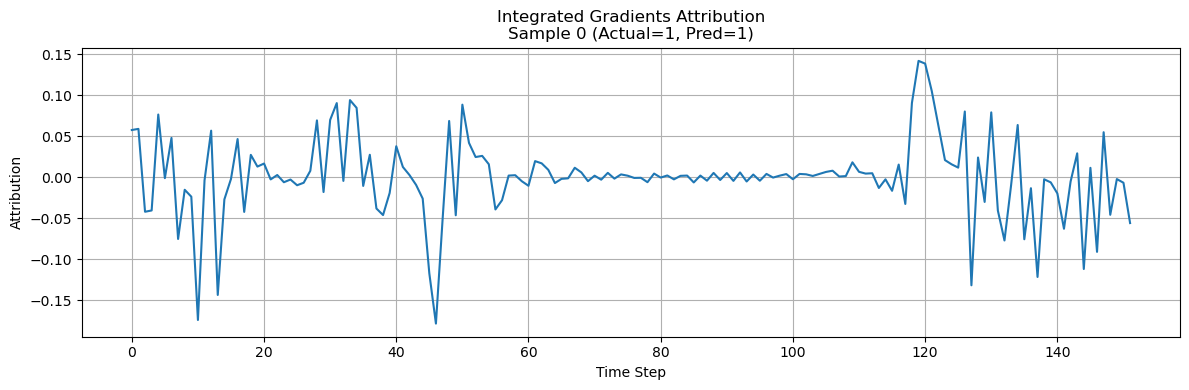

In [ ]:
idx = case_1_indices[0]
sample = tf.convert_to_tensor(X_test[idx:idx+1], dtype=tf.float32)
baseline = tf.zeros_like(sample)

ig_attrib = integrated_gradients(model, baseline, sample)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(ig_attrib)
plt.title("Integrated Gradients Attribution\nSample 0 (Actual=1, Pred=1)")
plt.xlabel("Time Step")
plt.ylabel("Attribution")
plt.grid(True)
plt.tight_layout()
plt.show()

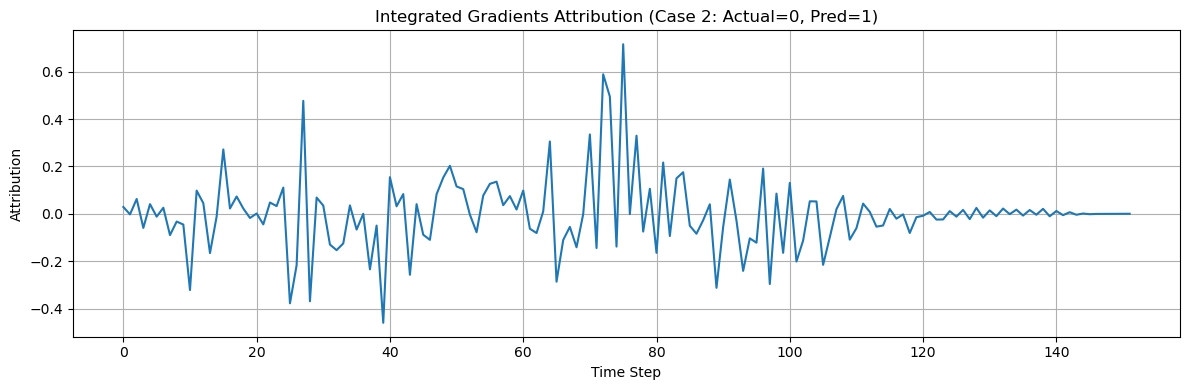

In [ ]:
# CASE 2: Actual = 0, Predicted = 1
sample_idx = case_2_indices[0]  # Select first sample from case 2
sample = tf.convert_to_tensor(X_test[sample_idx:sample_idx+1], dtype=tf.float32)
baseline = tf.zeros_like(sample)

# Compute Integrated Gradients
ig_attrib = integrated_gradients(model, baseline, sample)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(ig_attrib)
plt.title("Integrated Gradients Attribution (Case 2: Actual=0, Pred=1)")
plt.xlabel("Time Step")
plt.ylabel("Attribution")
plt.grid(True)
plt.tight_layout()
plt.show()

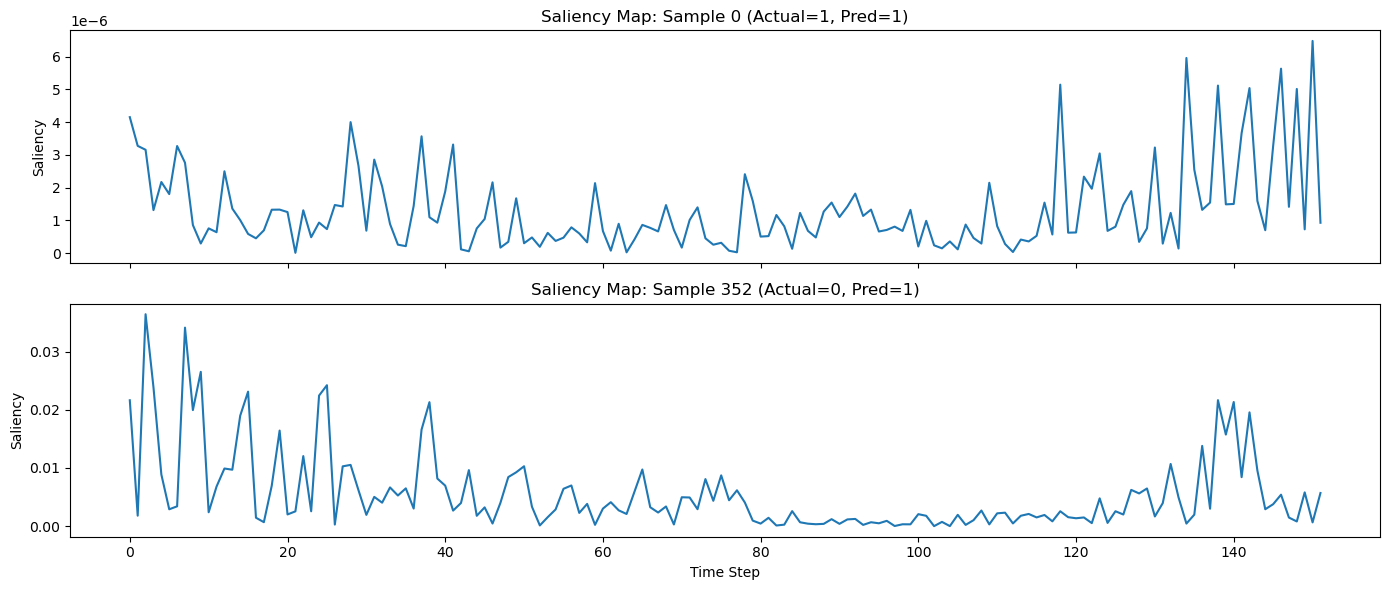

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Function to compute saliency map
def compute_saliency_map(model, sample):
    sample = tf.convert_to_tensor(sample)
    sample = tf.cast(sample, tf.float32)
    sample = tf.Variable(sample)

    with tf.GradientTape() as tape:
        tape.watch(sample)
        prediction = model(sample, training=False)
        loss = prediction[:, 0]  # For binary classification

    gradient = tape.gradient(loss, sample)
    saliency = tf.reduce_max(tf.abs(gradient), axis=-1).numpy()  # (1, time_steps)
    return saliency[0]

# Select your test samples
sample_1 = X_test[0:1]      # Actual=1, Pred=1
sample_2 = X_test[352:353]  # Actual=0, Pred=1

# Compute saliency maps
saliency_1 = compute_saliency_map(model, sample_1)
saliency_2 = compute_saliency_map(model, sample_2)

# Plot results
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(saliency_1)
axes[0].set_title("Saliency Map: Sample 0 (Actual=1, Pred=1)")
axes[0].set_ylabel("Saliency")

axes[1].plot(saliency_2)
axes[1].set_title("Saliency Map: Sample 352 (Actual=0, Pred=1)")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Saliency")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def integrated_gradients(model, baseline, sample, target_class_idx=0, m_steps=50):
    alphas = tf.linspace(start=0.0, stop=1.0, num=m_steps + 1)

    # Remove extra batch dimension if exists, then interpolate
    baseline = tf.squeeze(baseline)  # (152, 1)
    sample = tf.squeeze(sample)      # (152, 1)

    interpolated = [baseline + tf.cast(alpha, tf.float32) * (sample - baseline) for alpha in alphas]
    interpolated = tf.stack(interpolated)            # shape: (51, 152, 1)

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated, training=False)  # expects (batch, 152, 1)
        outputs = preds[:, target_class_idx]

    grads = tape.gradient(outputs, interpolated)     # shape: (51, 152, 1)
    avg_grads = tf.reduce_mean(grads, axis=0)        # shape: (152, 1)

    ig = (sample - baseline) * avg_grads             # shape: (152, 1)
    return ig

In [ ]:
# --- STEP 2: Select samples by class ---
X_normal = X_test[y_test == 1][:100]     # class 1: normal
X_abnormal = X_test[y_test == 0][:100]   # class 0: abnormal

def compute_mean_ig(X_subset, model, m_steps=50):
    all_ig = []
    baseline = tf.zeros((152, 1), dtype=tf.float32)  # remove batch dimension

    for x in X_subset:
        sample = tf.convert_to_tensor(x.reshape(152, 1), dtype=tf.float32)  # also remove batch dim
        ig = integrated_gradients(model, baseline, sample, m_steps=m_steps)
        all_ig.append(tf.squeeze(ig))  # (152,)

    stacked = tf.stack(all_ig)  # (N, 152)
    mean_ig = tf.reduce_mean(tf.abs(stacked), axis=0)
    return mean_ig.numpy()

mean_ig_normal = compute_mean_ig(X_normal, model)
mean_ig_abnormal = compute_mean_ig(X_abnormal, model)

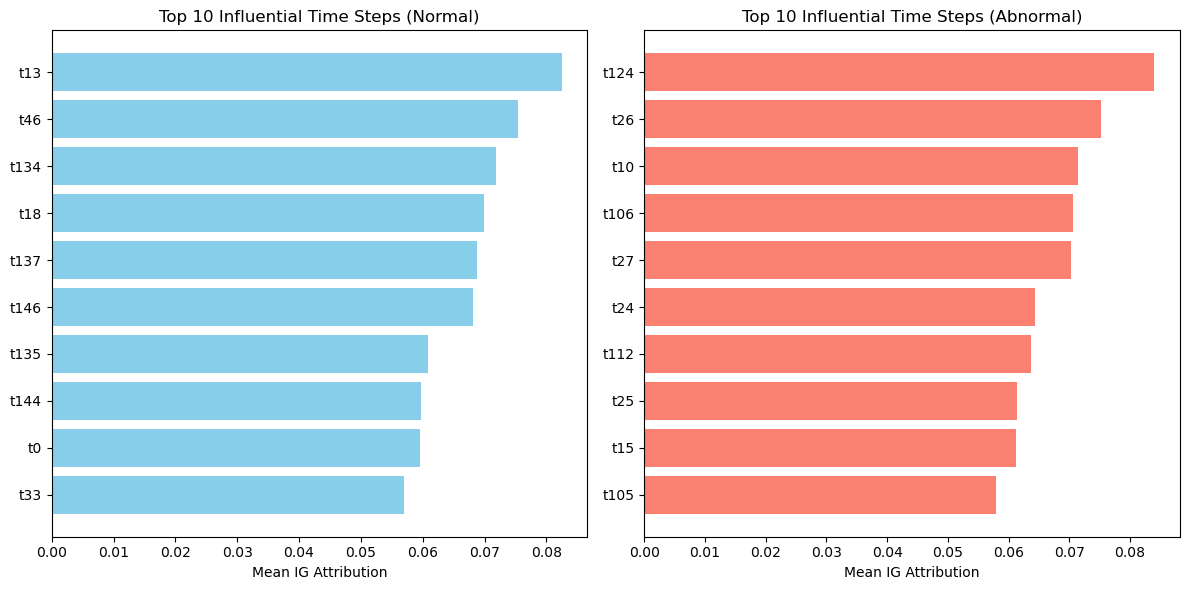

In [ ]:
# --- STEP 4: Top-k indexing ---
top_k = 10
top_idx_normal = np.argsort(mean_ig_normal)[-top_k:][::-1]
top_idx_abnormal = np.argsort(mean_ig_abnormal)[-top_k:][::-1]

# --- STEP 5: Plot side-by-side bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot for normal
axes[0].barh([f't{i}' for i in top_idx_normal[::-1]], mean_ig_normal[top_idx_normal[::-1]], color='skyblue')
axes[0].set_title('Top 10 Influential Time Steps (Normal)')
axes[0].set_xlabel('Mean IG Attribution')

# Plot for abnormal
axes[1].barh([f't{i}' for i in top_idx_abnormal[::-1]], mean_ig_abnormal[top_idx_abnormal[::-1]], color='salmon')
axes[1].set_title('Top 10 Influential Time Steps (Abnormal)')
axes[1].set_xlabel('Mean IG Attribution')

plt.tight_layout()
plt.show()

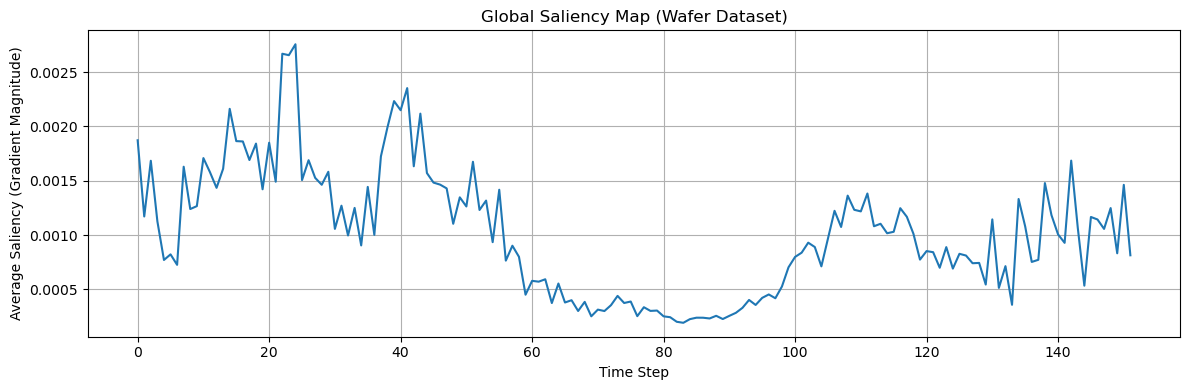

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Compute gradients w.r.t input (Saliency)
def compute_global_saliency(model, X_data):
    grads_list = []
    for i in range(len(X_data)):
        x = tf.convert_to_tensor(X_data[i:i+1], dtype=tf.float32)
        with tf.GradientTape() as tape:
            tape.watch(x)
            pred = model(x, training=False)
        grad = tape.gradient(pred, x)  # shape: (1, 152, 1)
        grads_list.append(tf.abs(grad).numpy().squeeze())  # (152,)

    # Average across all samples
    global_saliency = np.mean(grads_list, axis=0)
    return global_saliency

# Run on test data
global_saliency = compute_global_saliency(model, X_test)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(global_saliency)
plt.title("Global Saliency Map (Wafer Dataset)")
plt.xlabel("Time Step")
plt.ylabel("Average Saliency (Gradient Magnitude)")
plt.grid(True)
plt.tight_layout()
plt.show()